# Lab 02 — Overfit One Batch

**Goal:** perform a real supervised update and understand every important line.

We intentionally train on a tiny dataset until Qwen3-0.6B memorizes it.

This is not useful Wordle training. It is a diagnostic exercise. If we cannot make a model overfit 16–32 examples, a larger training run is just a more expensive mystery.

In [1]:
import math
import random
import torch
from torch.optim import AdamW
from transformers import AutoModelForCausalLM, AutoTokenizer
from tiny_wordle.hardware import preferred_device

MODEL_ID = "Qwen/Qwen3-0.6B"
device = preferred_device()

torch.manual_seed(42)
random.seed(42)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32,
).to(device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

## 2.1 The tiny dataset

We use deliberately synthetic mappings so memorization is obvious.

Each training example says: given a compact Wordle state, emit one exact next guess.

In [2]:
examples = [
    ("State A01. Next guess?", "CRANE"),
    ("State A02. Next guess?", "SLATE"),
    ("State A03. Next guess?", "AUDIO"),
    ("State A04. Next guess?", "POINT"),
    ("State A05. Next guess?", "SHORE"),
    ("State A06. Next guess?", "BLIND"),
    ("State A07. Next guess?", "MIGHT"),
    ("State A08. Next guess?", "ROUND"),
    ("State A09. Next guess?", "CHAMP"),
    ("State A10. Next guess?", "FLING"),
    ("State A11. Next guess?", "BRICK"),
    ("State A12. Next guess?", "GHOST"),
    ("State A13. Next guess?", "PLUMB"),
    ("State A14. Next guess?", "WASTE"),
    ("State A15. Next guess?", "KNIFE"),
    ("State A16. Next guess?", "DOUBT"),
]

len(examples)

16

## 2.2 Build labels correctly

For causal-LM SFT, the model sees prompt + answer. But we usually do **not** want to train it to reproduce the user's prompt.

PyTorch's cross-entropy implementation ignores label positions set to `-100`.

So our labels will be:

```text
prompt tokens    answer tokens
-100 -100 ...    actual token IDs
```

That tiny detail is central to supervised fine-tuning.

In [3]:
def encode_example(prompt_text: str, answer: str):
    messages_without_answer = [
        {"role": "user", "content": prompt_text},
    ]
    prompt = tokenizer.apply_chat_template(
        messages_without_answer,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    full_text = prompt + answer + tokenizer.eos_token

    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]

    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    assert len(labels) == len(full_ids)

    return full_ids, labels

ids, labels = encode_example(*examples[0])
print("tokens:", tokenizer.convert_ids_to_tokens(ids))
print("labels:", labels)

tokens: ['<|im_start|>', 'user', 'Ċ', 'State', 'ĠA', '0', '1', '.', 'ĠNext', 'Ġguess', '?', '<|im_end|>', 'Ċ', '<|im_start|>', 'assistant', 'Ċ', '<think>', 'ĊĊ', '</think>', 'ĊĊ', 'CR', 'ANE', '<|im_end|>']
labels: [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 8973, 27819, 151645]


## 2.3 Collate the batch

Padding tokens should also be ignored in the loss.

In [4]:
encoded = [encode_example(*ex) for ex in examples]
max_len = max(len(ids) for ids, _ in encoded)

pad_id = tokenizer.pad_token_id
if pad_id is None:
    pad_id = tokenizer.eos_token_id

input_rows = []
label_rows = []
attention_rows = []

for ids, labels in encoded:
    pad = max_len - len(ids)
    input_rows.append(ids + [pad_id] * pad)
    label_rows.append(labels + [-100] * pad)
    attention_rows.append([1] * len(ids) + [0] * pad)

input_ids = torch.tensor(input_rows, dtype=torch.long, device=device)
labels = torch.tensor(label_rows, dtype=torch.long, device=device)
attention_mask = torch.tensor(attention_rows, dtype=torch.long, device=device)

print("input_ids:", input_ids.shape)
print("labels:", labels.shape)
print("supervised token count:", (labels != -100).sum().item())

input_ids: torch.Size([16, 24])
labels: torch.Size([16, 24])
supervised token count: 46


## 2.4 Measure before training

Never train without a before-state.

In [5]:
def answer(prompt_text: str, max_new_tokens=12):
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt_text}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    batch = tokenizer(prompt, return_tensors="pt").to(device)
    model.eval()
    with torch.no_grad():
        out = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )
    new = out[0, batch["input_ids"].shape[1]:]
    return tokenizer.decode(new, skip_special_tokens=True).strip()

for prompt_text, expected in examples[:5]:
    print(prompt_text, "| expected:", expected, "| model:", answer(prompt_text))

State A01. Next guess? | expected: CRANE | model: Next guess: **A01.1**
State A02. Next guess? | expected: SLATE | model: Next guess: **A02.02.0
State A03. Next guess? | expected: AUDIO | model: Next guess: **A03.0000
State A04. Next guess? | expected: POINT | model: Next guess: **A04.0000
State A05. Next guess? | expected: SHORE | model: Next guess: **A06. The Great Barrier Reef


## 2.5 Inspect the loss before updating

`AutoModelForCausalLM` performs the next-token shift internally when `labels=` is supplied.

In [8]:
model.train()

out = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels,
)

loss_value = out.loss.detach().item()

print("initial loss:", loss_value)
print("perplexity over supervised tokens:", math.exp(loss_value))

initial loss: 12.393598556518555
perplexity over supervised tokens: 241252.30088877614


## 2.6 One optimizer step, explicitly

This is the core loop we will keep returning to:

1. forward pass
2. compute loss
3. backpropagate gradients
4. update parameters
5. clear gradients

Nothing mystical is hiding here.

In [9]:
optimizer = AdamW(model.parameters(), lr=2e-5)

optimizer.zero_grad(set_to_none=True)

out = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels,
)

loss = out.loss
loss.backward()

grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()

print("loss:", float(loss))
print("gradient norm before clipping:", float(grad_norm))

loss: 12.393598556518555
gradient norm before clipping: 481.2053527832031


## 2.7 Intentionally overfit

We use the **same batch repeatedly**. In normal training this would be terrible. Here it is exactly the test.

Watch whether the loss can collapse.

In [10]:
optimizer = AdamW(model.parameters(), lr=1e-4)

history = []
steps = 120

model.train()
for step in range(1, steps + 1):
    optimizer.zero_grad(set_to_none=True)

    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
    )
    loss = out.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    history.append(float(loss.detach().cpu()))

    if step == 1 or step % 10 == 0:
        print(f"step {step:3d} | loss {history[-1]:.4f}")

step   1 | loss 4.2353
step  10 | loss 1.2506
step  20 | loss 0.2129
step  30 | loss 0.0001
step  40 | loss 0.0000
step  50 | loss 0.0000
step  60 | loss 0.0000
step  70 | loss 0.0000
step  80 | loss 0.0000
step  90 | loss 0.0000
step 100 | loss 0.0000
step 110 | loss 0.0000
step 120 | loss 0.0000


Plot the training loss. The shape matters more than the final number.

Matplotlib is building the font cache; this may take a moment.


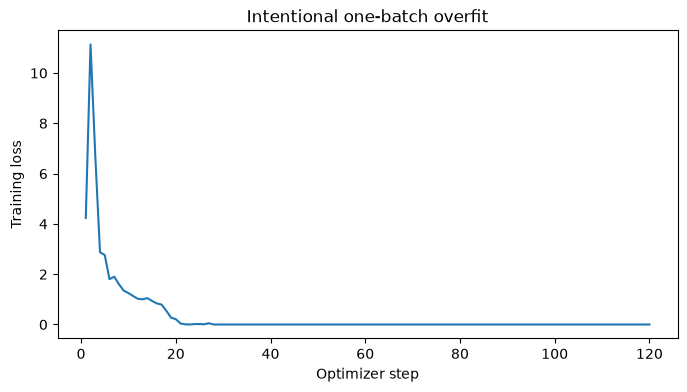

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history)
plt.xlabel("Optimizer step")
plt.ylabel("Training loss")
plt.title("Intentional one-batch overfit")
plt.show()

## 2.8 Did behavior actually change?

Loss is not the product. Behavior is.

Evaluate the same prompts again.

In [12]:
correct = 0
for prompt_text, expected in examples:
    actual = answer(prompt_text).split()[0].strip(".,:;!?").upper()
    ok = actual == expected
    correct += int(ok)
    print(f"{'✓' if ok else '✗'} {prompt_text:24s} expected={expected:5s} actual={actual}")

print(f"\nExact memorization: {correct}/{len(examples)}")

✓ State A01. Next guess?   expected=CRANE actual=CRANE
✓ State A02. Next guess?   expected=SLATE actual=SLATE
✓ State A03. Next guess?   expected=AUDIO actual=AUDIO
✓ State A04. Next guess?   expected=POINT actual=POINT
✓ State A05. Next guess?   expected=SHORE actual=SHORE
✓ State A06. Next guess?   expected=BLIND actual=BLIND
✓ State A07. Next guess?   expected=MIGHT actual=MIGHT
✓ State A08. Next guess?   expected=ROUND actual=ROUND
✓ State A09. Next guess?   expected=CHAMP actual=CHAMP
✓ State A10. Next guess?   expected=FLING actual=FLING
✓ State A11. Next guess?   expected=BRICK actual=BRICK
✓ State A12. Next guess?   expected=GHOST actual=GHOST
✓ State A13. Next guess?   expected=PLUMB actual=PLUMB
✓ State A14. Next guess?   expected=WASTE actual=WASTE
✓ State A15. Next guess?   expected=KNIFE actual=KNIFE
✓ State A16. Next guess?   expected=DOUBT actual=DOUBT

Exact memorization: 16/16


## 2.9 A control the model never saw

Now ask for `State A17`.

What do you expect? Why is this distinction between memorization and generalization the entire reason we need train/validation/test splits later?

In [13]:
print(answer("State A17. Next guess?"))

MIGHT


## 2.10 What changed in the weights?

Pick one parameter tensor and compare it conceptually with the original checkpoint.

For now we simply inspect gradient/update scale. Later we will measure layer-wise changes and compare full fine-tuning against LoRA.

In [14]:
name, parameter = next((n, p) for n, p in model.named_parameters() if p.requires_grad and p.ndim >= 2)
print("example parameter:", name)
print("shape:", tuple(parameter.shape))
print("mean abs value:", parameter.detach().abs().mean().item())

example parameter: model.embed_tokens.weight
shape: (151936, 1024)
mean abs value: 0.02300935797393322


## Lab 02 checkpoint

You should now be able to explain, without hand-waving:

- what the training examples contain;
- why prompt tokens are masked with `-100`;
- what cross-entropy loss is scoring;
- what `loss.backward()` creates;
- what the optimizer changes;
- why gradients are cleared;
- why memorizing the batch proves something useful but says nothing about generalization;
- why "loss went down" is insufficient evidence of useful learning.

### Experiment note

Record:

- initial loss;
- final loss;
- exact memorization accuracy;
- behavior on the unseen `A17` state;
- anything suspicious or unexpected.

Next: we build Wordle itself and stop using toy labels.